In [1]:
import awkward as ak
import numpy as np
import uproot
import torch

import sys
from functools import partial
from pathlib import Path

# Get parent of current working directory (or notebook location)
project_root = Path.cwd().parent

sys.path.append(str(project_root))

print("Added to PYTHONPATH:", project_root)
from user_scripts.branches_to_get import get_branchDict
from utils.vtxLevelDataset import ModifiedUprootIterator
from user_scripts import preprocess_K0_nominal
from user_scripts import preprocess_K0_alternative

Added to PYTHONPATH: /groups/hephy/cms/alikaan.gueven/ParT/runs/vtx_PART-1065_IVF


In [2]:
file = '/scratch-cbe/users/alikaan.gueven/ML_KAAN/20260112/GNN_test/wjetstolnuht0600_2018/wjetstolnuht0600_2018__merged_000.root'
testDict = {'sig': [file + ':Events'],
            'bkg': []}


branchDict = get_branchDict()

nWorkers = 1
step_size = 10_000



nominalDataset = ModifiedUprootIterator(testDict, 
                                         branchDict,
                                         shuffle=False,
                                         nWorkers=nWorkers,
                                         step_size=step_size)


preprocess_fn = partial(preprocess_K0_nominal.transform, branch_dict=branchDict)
nominalLoader = torch.utils.data.DataLoader(nominalDataset,
                                            num_workers=nWorkers,
                                            prefetch_factor=1,
                                            persistent_workers= True,
                                            collate_fn=preprocess_fn,
                                            pin_memory=True)



alternativeDataset = ModifiedUprootIterator(testDict, 
                                            branchDict,
                                            shuffle=False,
                                            nWorkers=nWorkers,
                                            step_size=step_size)


preprocess_fn_funny = partial(preprocess_K0_alternative.transform, branch_dict=branchDict)
alternativeLoader = torch.utils.data.DataLoader(alternativeDataset,
                                                num_workers=nWorkers,
                                                prefetch_factor=1,
                                                persistent_workers= True,
                                                collate_fn=preprocess_fn_funny,
                                                pin_memory=True)

Initialize iterable dataset
nWorkers:  1
Initialize iterable dataset
nWorkers:  1


In [3]:
iterator = alternativeLoader.__iter__()
out_dict = iterator.__next__()

__iter__ is called.
__iter__ is called.


In [4]:
for k,v in out_dict.items():
    print(k, v.shape)

tk_pair_features torch.Size([1485, 4, 10])
tk_features torch.Size([1485, 7, 10])
tk_mask torch.Size([1485, 1, 10])
sv_features torch.Size([1485, 8, 1])
label torch.Size([1485, 1])


In [5]:
MODEL_PATH = '/groups/hephy/cms/alikaan.gueven/ParT/models/vtx_PART-1065_epoch_18.pt'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = torch.load(MODEL_PATH, map_location=torch.device(device))
if isinstance(model, torch.nn.DataParallel):
    model = model.module

model.to(device)
model.eval()


iterator = nominalLoader.__iter__()
out_dict = iterator.__next__()
output = model(x=out_dict['tk_features'],
               v=out_dict['tk_pair_features'],
               x_sv=out_dict['sv_features'],
               mask=out_dict['tk_mask'])
output_softmax = torch.softmax(output, dim=1)
nominal_MLScore = output_softmax[:,1].detach().cpu().numpy()


iterator = alternativeLoader.__iter__()
out_dict = iterator.__next__()
output = model(x=out_dict['tk_features'],
               v=out_dict['tk_pair_features'],
               x_sv=out_dict['sv_features'],
               mask=out_dict['tk_mask'])
output_softmax = torch.softmax(output, dim=1)
alternative_MLScore = output_softmax[:,1].detach().cpu().numpy()

__iter__ is called.


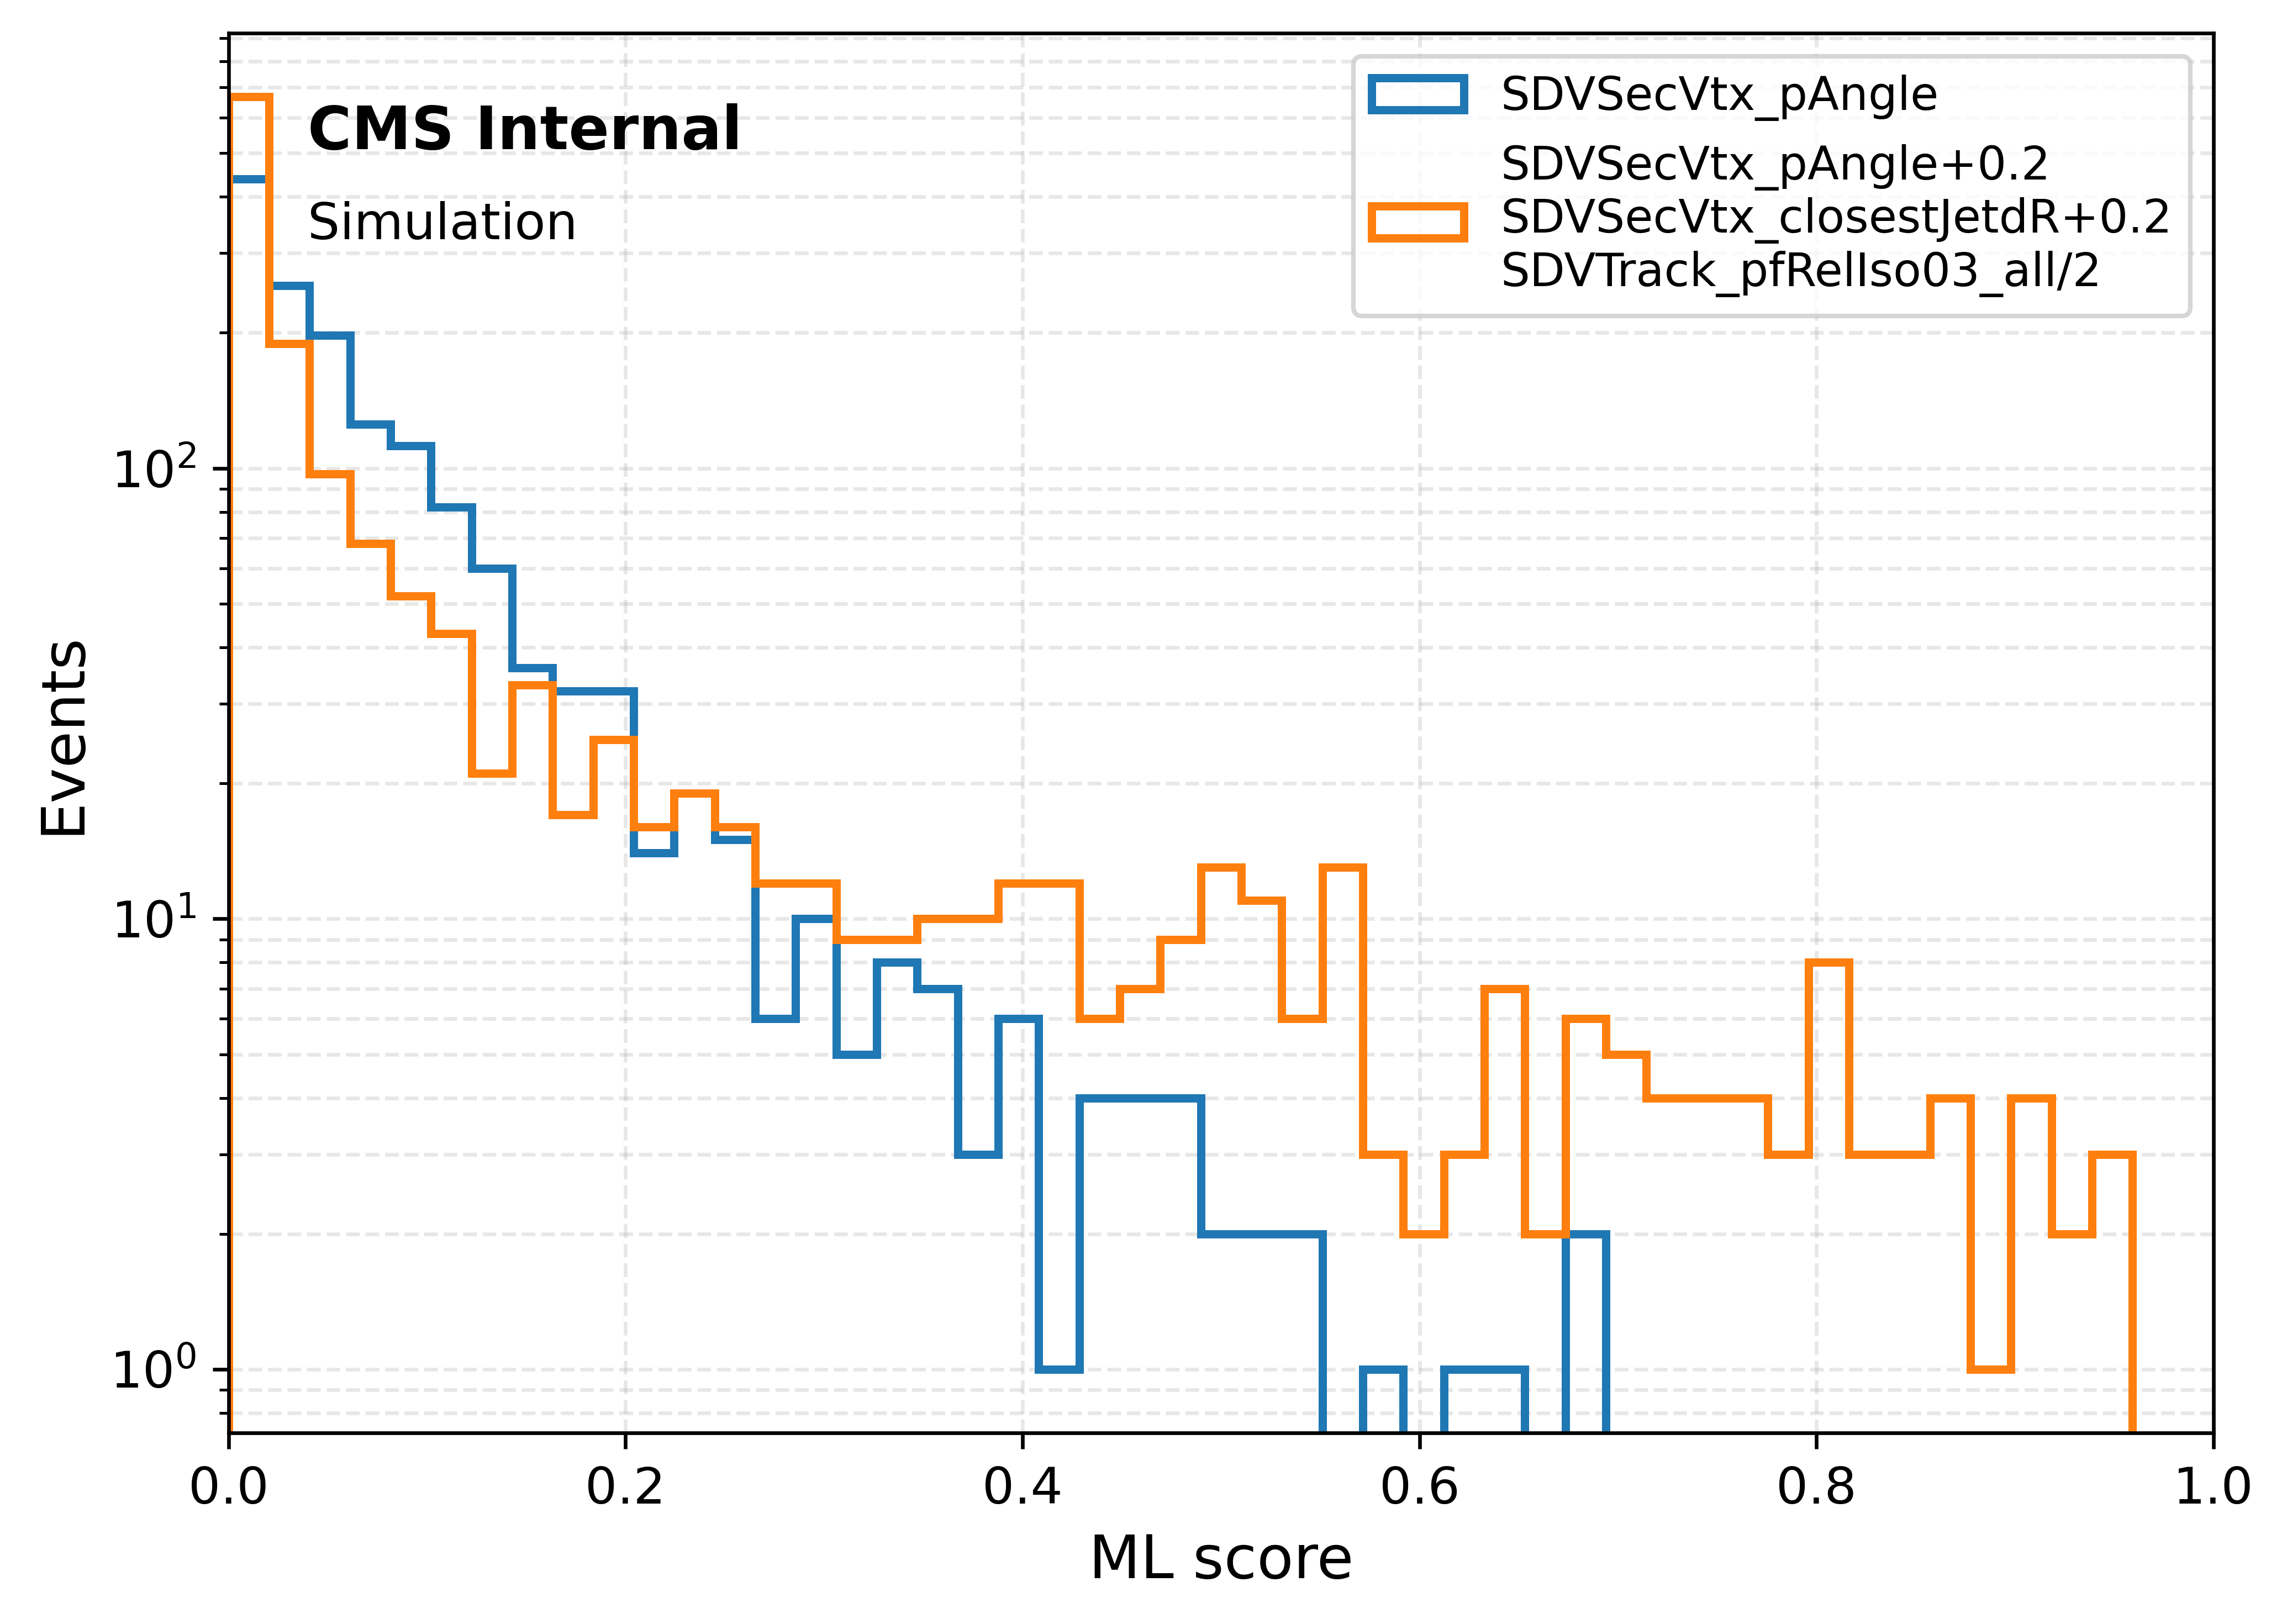

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(7, 5), dpi=600)


bins = np.linspace(0, 1, 50)

# Histogram
plt.hist(
    nominal_MLScore,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    label='SDVSecVtx_pAngle'
)
plt.hist(
    alternative_MLScore,
    bins=bins,
    histtype="step",
    linewidth=1.8,
    label='SDVSecVtx_pAngle+0.2\nSDVSecVtx_closestJetdR+0.2\nSDVTrack_pfRelIso03_all/2'
)

# Log scale
plt.yscale("log")

# Labels
plt.xlabel("ML score", fontsize=13)
plt.ylabel("Events", fontsize=13)

# Limits
plt.xlim(0, 1)

# Grid (nice for log scale)
plt.grid(True, which="both", linestyle="--", alpha=0.3)

# Ticks style
plt.tick_params(axis='both', which='major', labelsize=11)
plt.tick_params(axis='both', which='minor', labelsize=9)

# Optional: experiment-style text
plt.text(
    0.04, 0.95,
    "CMS Internal",
    transform=plt.gca().transAxes,
    fontsize=13,
    fontweight="bold",
    verticalalignment="top"
)

# Optional: description
plt.text(
    0.04, 0.88,
    "Simulation",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)
plt.legend()
# Tight layout
plt.tight_layout()

plt.show()


In [7]:
# K0_filter = ((x.SDVSecVtx_mass < 0.517) & (x.SDVSecVtx_mass > 0.477) &
#              (x.SDVSecVtx_pAngle < 0.2) & (x.SDVSecVtx_nTracks == 2) &
#              (x.SDVSecVtx_charge == 0)
#              )
# x.SDVSecVtx_ndof[K0_filter]